<a href="https://colab.research.google.com/github/KassiaLopes/Mercado-Orbita/blob/main/mercado_orbita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Mercado Órbita

# Objetivos e Dores Atuais
- Diminuir o atraso nas entregas de 2,3 para 1,7 dias
- Aumentar a taxa de clientes recorrentes de 12% para 15%
- Aumentar a nota média de avaliação de 4,1 para 4,4

Nos últimos trimestres, o Mercado Órbita identificou as seguintes dores operacionais:
-  22% dos pedidos têm atrasos superiores a 2 dias.
-  18% das avaliações de clientes são abaixo de 3 estrelas.
- A taxa de clientes que voltam a comprar está estagnada em 12%.
- Essas métricas estão comprometendo o crescimento e a reputação da marca.

# Fase ETL

Ferramentas: Python e PowerBI

## Descobertas

- Discrepâncias entre as métricas reportadas e as calculadas a partir dos dados.
- Metas foram definidas com base em dados inconsistentes.

In [ ]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt

In [ ]:
seller_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_sellers_dataset.csv'
orders_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_orders_dataset.csv'
products_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_products_dataset.csv'
customers_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_customers_dataset.csv'
reviews_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_order_reviews_dataset.csv'
payments_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_order_payments_dataset.csv'
itens_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/olist_order_items_dataset.csv'
translation_ds = 'https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/refs/heads/main/data/raw/product_category_name_translation.csv'

In [ ]:
tabela_info_clientes = pd.read_csv(customers_ds)
tabela_pedidos = pd.read_csv(orders_ds)
tabela_itens_pedido = pd.read_csv(itens_ds)
tabela_avaliacoes = pd.read_csv(reviews_ds)
tabela_info_produtos = pd.read_csv(products_ds)
tabela_vendedores = pd.read_csv(seller_ds)
tabela_pagamentos = pd.read_csv(payments_ds)

#'olist_sellers_dataset.csv'
#'olist_orders_dataset.csv'
#'olist_products_dataset.csv'
#'olist_customers_dataset.csv'
#'olist_order_reviews_dataset.csv'
#'olist_order_payments_dataset.csv'
#'olist_order_items_dataset.csv'

# 1- Análise Inicial dos Dados

## 1.1 Visualização prévia dos dados de cada tabela


In [ ]:
tabela_info_clientes.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [ ]:
tabela_pedidos.head(3)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [ ]:
tabela_itens_pedido.head(3)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [ ]:
tabela_avaliacoes.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [ ]:
tabela_info_produtos.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [ ]:
tabela_vendedores.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


In [ ]:
tabela_pagamentos.head(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


## 1.2 - Análise dos Tipos de Dados

In [ ]:
tabela_info_clientes.info(), tabela_info_clientes.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


(None,
 customer_id                 99441
 customer_unique_id          96096
 customer_zip_code_prefix    14994
 customer_city                4119
 customer_state                 27
 dtype: int64)

In [ ]:
tabela_pedidos.info(), tabela_pedidos.nunique()
tabela_pedidos['order_status'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [ ]:
tabela_itens_pedido.info(), tabela_itens_pedido.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


(None,
 order_id               98666
 order_item_id             21
 product_id             32951
 seller_id               3095
 shipping_limit_date    93318
 price                   5968
 freight_value           6999
 dtype: int64)

In [ ]:
tabela_avaliacoes.info(), tabela_avaliacoes.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


(None,
 review_id                  98410
 order_id                   98673
 review_score                   5
 review_comment_title        4527
 review_comment_message     36159
 review_creation_date         636
 review_answer_timestamp    98248
 dtype: int64)

In [ ]:
tabela_info_produtos.info(), tabela_info_produtos.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


(None,
 product_id                    32951
 product_category_name            73
 product_name_lenght              66
 product_description_lenght     2960
 product_photos_qty               19
 product_weight_g               2204
 product_length_cm                99
 product_height_cm               102
 product_width_cm                 95
 dtype: int64)

In [ ]:
tabela_vendedores.info(), tabela_vendedores.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


(None,
 seller_id                 3095
 seller_zip_code_prefix    2246
 seller_city                611
 seller_state                23
 dtype: int64)

In [ ]:
tabela_pagamentos.info(), tabela_pagamentos.nunique()
tabela_pagamentos['payment_type'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

## 1.3 - Tratamento dos Dados

In [ ]:
# valores duplicados

print(tabela_avaliacoes.duplicated().sum())
print(tabela_info_clientes.duplicated().sum())
print(tabela_info_produtos.duplicated().sum())
print(tabela_itens_pedido.duplicated().sum())
print(tabela_pagamentos.duplicated().sum())
print(tabela_pedidos.duplicated().sum())
print(tabela_vendedores.duplicated().sum())

0
0
0
0
0
0
0


### 1.3.1 - Formatação das colunas de datas

In [ ]:
# Converter para datetime
tabela_pedidos[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']] = tabela_pedidos[['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']].apply(pd.to_datetime)


tabela_itens_pedido['shipping_limit_date'] = tabela_itens_pedido['shipping_limit_date'].apply(pd.to_datetime)

tabela_avaliacoes[['review_creation_date','review_answer_timestamp']] = tabela_avaliacoes[['review_creation_date','review_answer_timestamp']].apply(pd.to_datetime)


### Observações

**Tabela Clientes**

Entradas: 99441

Colunas:

- id (**valores únicos:** 99441, **valores nulos:** 0)
- unique_id (**valores únicos:** 96096, **valores nulos:** 0)
- code (**valores únicos:** 14994, **valores nulos:** 0)
- city (**valores únicos:** 4119, **valores nulos:** 0)
- state (**valores únicos:** 27, **valores nulos:** 0)

Tabela Pedidos

Entradas: 99441

Colunas:

- id (**valores únicos:** 99441, **valores nulos:** 0)
- custumer_id (**valores únicos:** 99441, **valores nulos:** 0)
- status (**valores únicos:** 8, **valores nulos:** 0)
    - delivered, invoiced, shipped, processing, unavailable, canceled, created, approved
- purchase (dia da compra) (**valores únicos:** 98875, **valores nulos:** 0)
- approved (**valores únicos:** 90733, **valores nulos:** 160)
- delivery_carrier (**valores únicos:** 81018, **valores nulos:** 1783)
- delivery_customer (**valores únicos:** 95664, **valores nulos:** 2965)
- estimated_delivery (**valores únicos:** 459, **valores nulos:** 0)

**Tabela Itens Pedidos**

Entradas: 112650

Colunas:
- order_id (**valores únicos:** 98666, **valores nulos:** 0)
- item_id (**valores únicos:** 21, **valores nulos:** 0)
- product_id (**valores únicos:** 32951, **valores nulos:** 0)
- seller_id (**valores únicos:** 3095, **valores nulos:** 0)
- shipping_limit_date (**valores únicos:** 93318, **valores nulos:** 0)
- price (**valores únicos:** 5968, **valores nulos:** 0)
- freight (**valores únicos:** 6999, **valores nulos:** 0)

**Tabela Avaliações**

Entradas: 99224

Colunas:
- review_id (**valores únicos:** 98410, **valores nulos:** 0)
- order_id (**valores únicos:** 98673, **valores nulos:** 0)
- review_score (**valores únicos:** 5, **valores nulos:** 0)
- title (**valores únicos:** 4527, **valores nulos:** 97656)
- message (**valores únicos:** 36159, **valores nulos:** 58247)
- date_creation (**valores únicos:** 636, **valores nulos:** 0)
- answer_timestamp (**valores únicos:** 98248, **valores nulos:** 0)

**Tabela Produtos**
Entradas: 32915

Colunas:
- id (**valores únicos:** 32951, **valores nulos:** 0)
- category (**valores únicos:** 73, **valores nulos:** 610)
- name (**valores únicos:** 66, **valores nulos:** 610)
- description (**valores únicos:** 2960, **valores nulos:** 610)
- photos_qtd (**valores únicos:** 19, **valores nulos:** 610)
- weight (**valores únicos:** 2204, **valores nulos:** 2)
- lenght (**valores únicos:** 99, **valores nulos:** 2)
- height (**valores únicos:** 192, **valores nulos:** 2)
- widht (**valores únicos:** 95, **valores nulos:** 2)

**Tabela Vendedores**

Entradas: 3095

Colunas:
- id (**valores únicos:** 3095, **valores nulos:** 0)
- code(**valores únicos:** 2246 , **valores nulos:** 0)
- city (**valores únicos:** 611, **valores nulos:** 0)
- state (**valores únicos:** 23, **valores nulos:** 0)

**Tabela Pagamentos**

Entradas: 103886

Colunas:
- order_id (**valores únicos:** 99440, **valores nulos:** 0)
- sequential(**valores únicos:** 29 , **valores nulos:** 0)
- type (**valores únicos:** 5, **valores nulos:** 0)
    - credit_car, boleto, voucher, debit_car, not_defined
- intalallments (**valores únicos:** 24, **valores nulos:** 0)
- value (**valores únicos:** 29077, **valores nulos:** 0)



---

**Tratamento dos Dados**

- Nenhum registro duplicado
- Optou-se por manter os registros que apresentavam valores nulos em algumas colunas, uma vez que essas informações não foram consideradas essenciais para a análise neste primeiro momento.
- As colunas com informações de data foram convertidas para o tipo adequado, possibilitando a realização de cálculos.

# 2 - Cálculo dos KPIs e Métricas Auxiliares

## 2.1 - Taxa de clientes recorrentes

clientes recorrentes = clientes únicos com + de 1 pedido/total de clientes únicos

In [ ]:
#juntar as tabelas clientes e pedidos
clientes_e_pedidos = pd.merge(tabela_info_clientes, tabela_pedidos, on = 'customer_id', how = 'inner')

#filtrar os pedidos entregues
pedidos_entregues = clientes_e_pedidos[(clientes_e_pedidos['order_status'] == 'delivered')]
pedidos_entregues.shape[0]

#Verificar quantos clientes únicos possuem + de 1 pedido

pedidos_por_cliente = clientes_e_pedidos.groupby('customer_unique_id')['order_id'].count()
qtd_clientes_recorrentes = pedidos_por_cliente[pedidos_por_cliente > 1].count()
print("Quantidade de clientes recorrentes: ",qtd_clientes_recorrentes)

# quantidade de clientes únicos
clientes_unicos = tabela_info_clientes['customer_unique_id'].nunique()

#taxa de clientes
tx_clientes_recorrentes = (qtd_clientes_recorrentes/clientes_unicos)*100
print("Taxa de clientes recorrentes: ", tx_clientes_recorrentes)

Quantidade de clientes recorrentes:  2997
Taxa de clientes recorrentes:  3.1187562437562435


## Vendedores por Estado
Análise da distribuição dos vendedores para auxiliar na análise de atraso das entregas.

In [ ]:
vendedores_por_estado = tabela_vendedores.groupby('seller_state')['seller_id'].count()
porcentagem = 100 * vendedores_por_estado / vendedores_por_estado.sum()

# Juntar em um DataFrame para facilitar visualização
df_vendedores = pd.DataFrame({
    'Quantidade': vendedores_por_estado,
    'Porcentagem (%)': porcentagem
}).sort_values(by='Quantidade', ascending=False)

print(df_vendedores)


              Quantidade  Porcentagem (%)
seller_state                             
SP                  1849        59.741519
PR                   349        11.276252
MG                   244         7.883683
SC                   190         6.138934
RJ                   171         5.525040
RS                   129         4.168013
GO                    40         1.292407
DF                    30         0.969305
ES                    23         0.743134
BA                    19         0.613893
CE                    13         0.420032
PE                     9         0.290792
PB                     6         0.193861
MS                     5         0.161551
RN                     5         0.161551
MT                     4         0.129241
RO                     2         0.064620
SE                     2         0.064620
AM                     1         0.032310
AC                     1         0.032310
PI                     1         0.032310
MA                     1         0

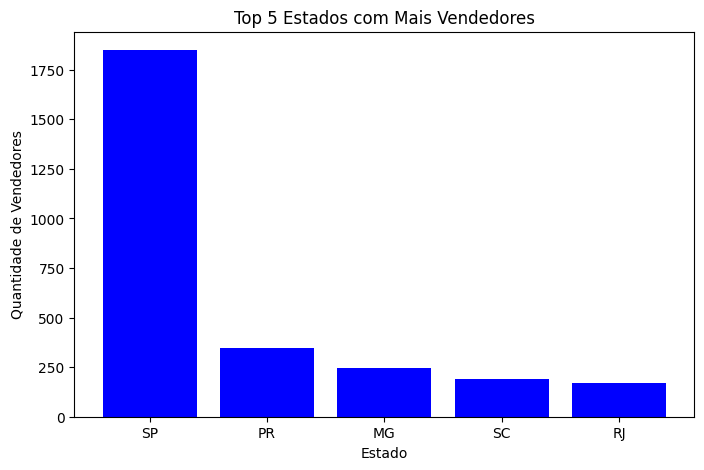

In [ ]:
top5_vendedores = df_vendedores.head(5)

plt.figure(figsize=(8, 5))
plt.bar(top5_vendedores.index, top5_vendedores['Quantidade'], color='blue')

plt.title('Top 5 Estados com Mais Vendedores')
plt.xlabel('Estado')
plt.ylabel('Quantidade de Vendedores')
plt.show()

## Pedidos Entregues por Estado

In [ ]:
#pedidos entregues por estado
pedidos_por_estado = pedidos_entregues.groupby('customer_state').size()

porcentagem_por_estado = 100 * pedidos_por_estado / pedidos_por_estado.sum()

df_por_estado = pd.DataFrame({
    'Quantidade': pedidos_por_estado,
    'Porcentagem (%)': porcentagem_por_estado
}).sort_values(by='Quantidade', ascending=False)

print(df_por_estado)


                Quantidade  Porcentagem (%)
customer_state                             
SP                   40501        41.979519
RJ                   12350        12.800846
MG                   11354        11.768486
RS                    5345         5.540123
PR                    4923         5.102718
SC                    3546         3.675449
BA                    3256         3.374863
DF                    2080         2.155932
ES                    1995         2.067829
GO                    1957         2.028442
PE                    1593         1.651154
CE                    1279         1.325691
PA                     946         0.980534
MT                     886         0.918344
MA                     717         0.743175
MS                     701         0.726591
PB                     517         0.535873
PI                     476         0.493377
RN                     474         0.491304
AL                     397         0.411493
SE                     335      

## 2.2 - Atraso Médio na Entrega

obs: Levar em consideração somente os pedidos entregues.


In [ ]:
#adicionando uma nova coluna para armazenar os dias de atraso

tabela_pedidos['dias_atraso'] = (tabela_pedidos['order_delivered_customer_date'] - tabela_pedidos['order_estimated_delivery_date']).dt.days

pedidos_entregues = tabela_pedidos[tabela_pedidos['order_status'] == 'delivered']
pedidos_atrasados = pedidos_entregues[pedidos_entregues['dias_atraso'] > 0]
pedidos_atrasados

media_atraso_entrega = pedidos_atrasados['dias_atraso'].mean()
print(f"Atraso médio em dias: {media_atraso_entrega: .2f}")

Atraso médio em dias:  10.62


### 2.2.1 - Pedidos com atraso superior a 2 dias

In [ ]:
#taxa pedidos com mais de dois dias de atraso
pedidos_com_atraso_maior_2 = tabela_pedidos[tabela_pedidos['dias_atraso'] > 2].shape[0]
pedidos_com_atraso_maior_2

qtd_entregues = pedidos_entregues.shape[0]

porcent_atraso_maior_2 = (pedidos_com_atraso_maior_2/qtd_entregues)*100
print("Taxa de pedidos com atraso superior a dois dias: ",porcent_atraso_maior_2)

Taxa de pedidos com atraso superior a dois dias:  5.353552105143142


## 2.3 - Pedidos Entregues e Percentual de Atrasos

Total de pedidos entregues: 96478
Pedidos com atraso > 2 dias: 5164
Percentual de atrasos > 2 dias: 5.35%
Pedidos com qualquer atraso (> 0 dias): 6534
Percentual de todos os atrasos: 6.77%
Média de dias de atraso (para pedidos atrasados): 10.62 dias


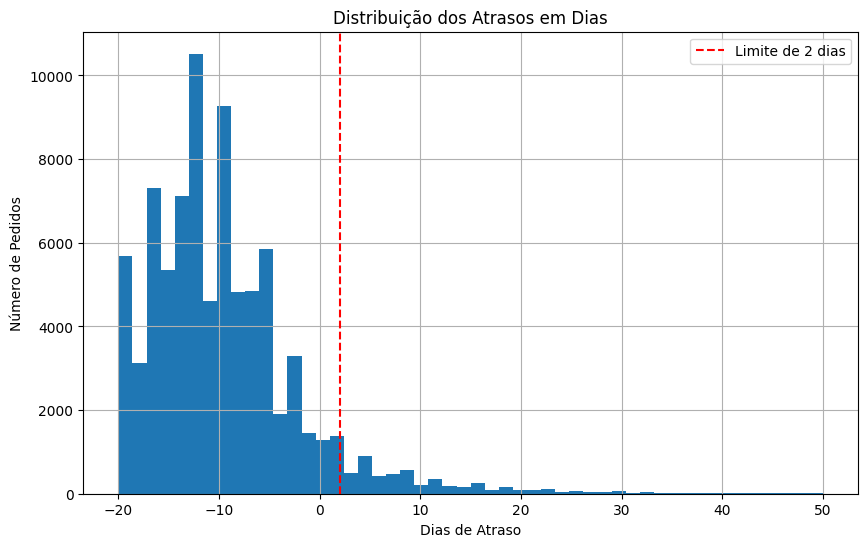

In [ ]:
# Configuração para gráficos
%matplotlib inline

# Função para carregar e preparar os dados
def carregar_dados():
    orders = pd.read_csv(orders_ds)

    # Converter colunas de data para datetime
    date_columns = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
    for col in date_columns:
        if col in orders.columns:
            orders[col] = pd.to_datetime(orders[col], errors='coerce')

    return orders

# Etapa 1: Validar métricas de atraso
def validar_atrasos(orders):
    # Filtrar pedidos entregues
    delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

    # Calcular atraso em dias
    delivered_orders['atraso_dias'] = (delivered_orders['order_delivered_customer_date'] -
                                      delivered_orders['order_estimated_delivery_date']).dt.days

    # Validar percentual de atrasos > 2 dias
    total_pedidos = len(delivered_orders)
    pedidos_atrasados_maior_2 = len(delivered_orders[delivered_orders['atraso_dias'] > 2])
    percent_atrasados_maior_2 = (pedidos_atrasados_maior_2 / total_pedidos) * 100

    # Validar percentual de todos os atrasos (> 0 dias)
    pedidos_atrasados_total = len(delivered_orders[delivered_orders['atraso_dias'] > 0])
    percent_atrasados_total = (pedidos_atrasados_total / total_pedidos) * 100

    # Calcular média de atrasos para pedidos atrasados
    media_atrasos = delivered_orders[delivered_orders['atraso_dias'] > 0]['atraso_dias'].mean()

    # Exibir resultados
    print(f"Total de pedidos entregues: {total_pedidos}")
    print(f"Pedidos com atraso > 2 dias: {pedidos_atrasados_maior_2}")
    print(f"Percentual de atrasos > 2 dias: {percent_atrasados_maior_2:.2f}%")
    print(f"Pedidos com qualquer atraso (> 0 dias): {pedidos_atrasados_total}")
    print(f"Percentual de todos os atrasos: {percent_atrasados_total:.2f}%")
    print(f"Média de dias de atraso (para pedidos atrasados): {media_atrasos:.2f} dias")

    # Visualização: Histograma de atrasos
    plt.figure(figsize=(10, 6))
    delivered_orders['atraso_dias'].hist(bins=50, range=(-20, 50))
    plt.axvline(x=2, color='red', linestyle='--', label='Limite de 2 dias')
    plt.title('Distribuição dos Atrasos em Dias')
    plt.xlabel('Dias de Atraso')
    plt.ylabel('Número de Pedidos')
    plt.legend()
    plt.show()

    return delivered_orders

# Função principal
def main():
    orders = carregar_dados()
    delivered_orders = validar_atrasos(orders)

if __name__ == "__main__":
    main()

### 2.3.1 -Atrasos por:
- Estado
- Vendedor
- Transportadora
- Categoria de Produtos

Dados carregados com sucesso.
Pedidos entregues para análise: 96478

=== Hipótese 1: Análise Geográfica (por Estado) ===
Iniciando Análise Geográfica...

Contribuição Percentual para Atrasos (> 2 dias) por estado do vendedor (%):
   seller_state  contribuicao_percentual_atraso  pedidos_atrasados
21           SP                       76.376027               4371
14           PR                        6.395247                366
7            MG                        5.923467                339
15           RJ                        4.490652                257
19           SC                        2.673423                153
6            MA                        1.100821                 63
18           RS                        1.048401                 60
3            DF                        0.629041                 36
1            BA                        0.401887                 23
4            ES                        0.262100                 15


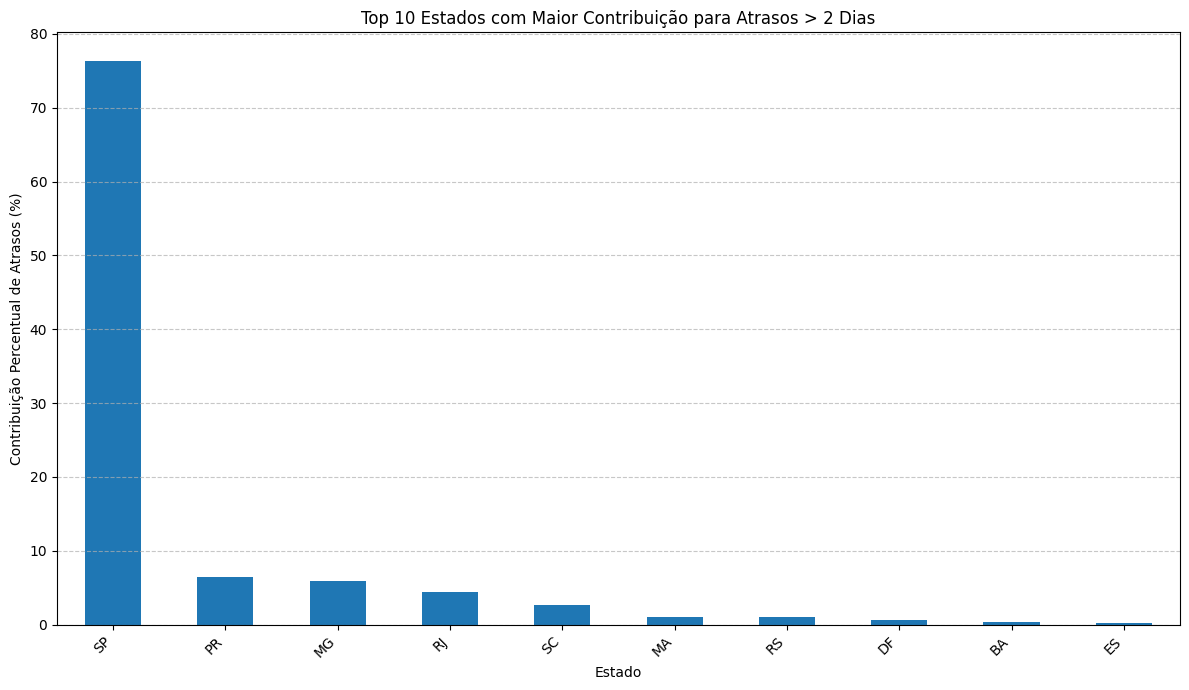


=== Hipótese 2: Análise de Vendedores (Tempo de Postagem) ===
Iniciando Análise de Vendedores...

Top 5 vendedores com maior tempo médio de postagem, número de pedidos e estado (com > 10 pedidos):
                             seller_id seller_state  tempo_medio_postagem  \
2751  ecccfa2bb93b34a3bf033cc5d1dcdc69           PR             25.125000   
1209  66e0557ecc2b4dbea057e93f215f68d8           SP             17.500000   
1000  54965bbe3e4f07ae045b90b0b8541f52           PR             15.123457   
933   5058e8c1e82653974541e83690655b4a           SP             14.844156   
2053  b1b3948701c5c72445495bd161b83a4c           SP             14.571429   

      num_pedidos  
2751           12  
1209           30  
1000           73  
933            62  
2053           14  


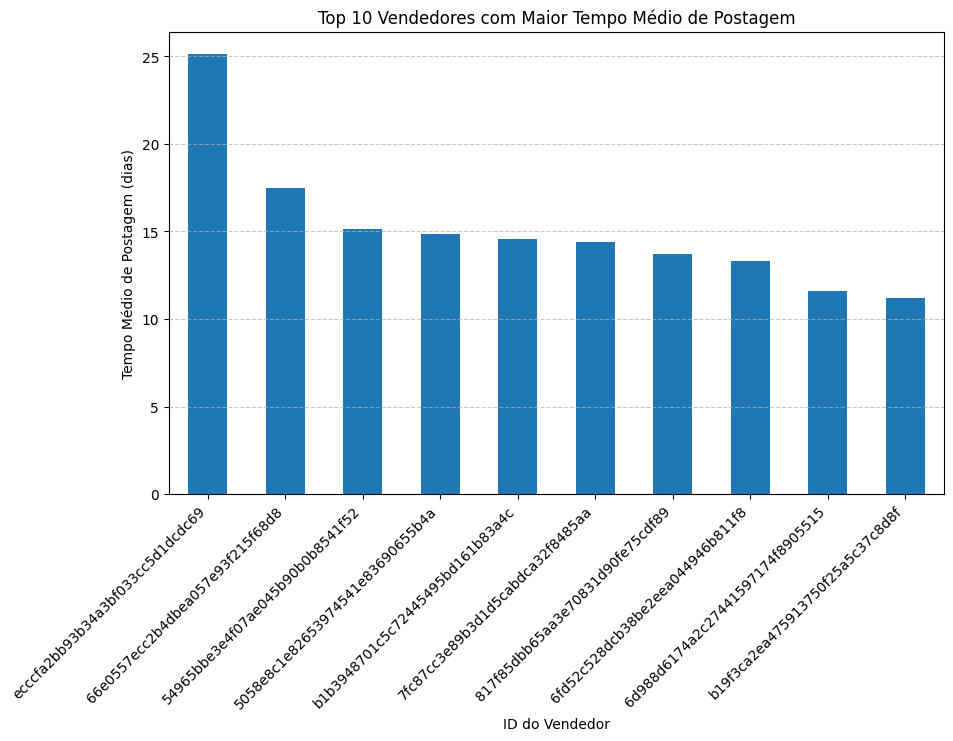


=== Hipótese 3: Análise de Transporte (Postagem vs. Entrega) ===
Iniciando Análise de Transporte...

Top 10 estados com maior número de pedidos atrasados (> 2 dias) e média de tempo de postagem/transporte:
              media_tempo_postagem  media_tempo_transporte  pedidos_atrasados
seller_state                                                                 
SP                        4.968657               29.256005               3935
PR                        9.210959               31.194521                330
MG                        6.834808               33.539823                301
RJ                        4.249027               29.785992                238
SC                        6.346405               34.215686                143
MA                       10.650794               21.031746                 63
RS                       12.966667               25.100000                 51
DF                        7.194444               30.388889                 31
BA           

<Figure size 1200x700 with 0 Axes>

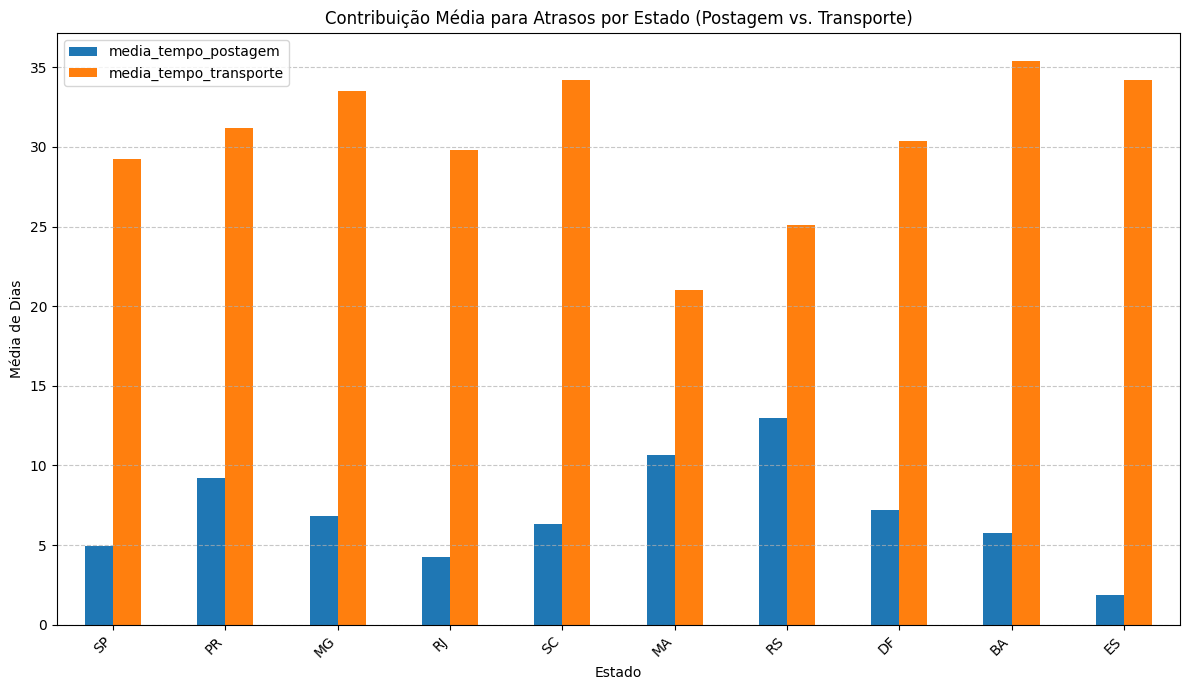


=== Hipótese 4: Análise por Tipo de Produto ===
Iniciando Análise por Tipo de Produto...
Dados combinados para análise de produtos: 110197 linhas.
Resultados por categoria (agrupados): 493 linhas.

Top 10 Combinações de Categoria de Produto e Estado com mais Pedidos Atrasados (> 2 dias):
    product_category_name_english seller_state  pedidos_atrasados  taxa_atraso
71                 bed_bath_table           SP                557     6.781105
307                 health_beauty           SP                387     6.808586
268               furniture_decor           SP                334     7.265608
448                sports_leisure           SP                299     6.265717
492                 watches_gifts           SP                278     6.186026
112         computers_accessories           SP                204     7.330219
347                    housewares           SP                203     5.048495
471                     telephony           SP                202     5.675752

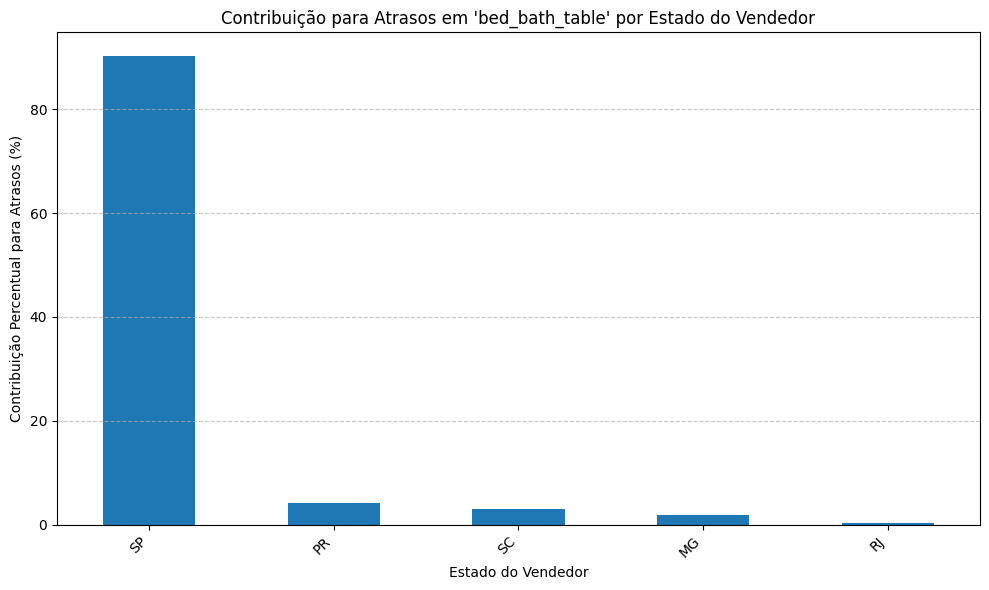

In [ ]:
def carregar_dados():
    try:
        orders = pd.read_csv(orders_ds)
        sellers = pd.read_csv(seller_ds)
        order_items = pd.read_csv(itens_ds)
        products = pd.read_csv(products_ds)
        translations = pd.read_csv(translation_ds)
        print("Dados carregados com sucesso.")



        return orders, sellers, order_items, products, translations
    except FileNotFoundError as e:
        print(f"Erro: Arquivo não encontrado. Verifique se o arquivo '{e.filename}' está no diretório correto.")
        raise

def preparar_dados_atrasos(orders):
    date_columns = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
    for col in date_columns:
        if col in orders.columns:
            orders[col] = pd.to_datetime(orders[col], errors='coerce')

    delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
    if delivered_orders.empty:
        print("Aviso: Nenhum pedido com status 'delivered' encontrado.")
        return delivered_orders

    delivered_orders['atraso_dias'] = (delivered_orders['order_delivered_customer_date'] -
                                       delivered_orders['order_estimated_delivery_date']).dt.days

    print(f"Pedidos entregues para análise: {delivered_orders.shape[0]}")
    return delivered_orders

def analise_geografica(delivered_orders, sellers, order_items):
    print("Iniciando Análise Geográfica...")
    order_items_sellers = order_items.merge(sellers, on='seller_id')
    atrasos_geo = delivered_orders.merge(order_items_sellers, on='order_id')

    resultados_por_estado = atrasos_geo.groupby('seller_state').agg(
        total_pedidos_estado=('order_id', 'nunique'),
        pedidos_atrasados=('atraso_dias', lambda x: (x > 2).sum())
    ).reset_index()

    if resultados_por_estado['pedidos_atrasados'].sum() == 0:
        print("Aviso: Nenhum pedido com atraso > 2 dias encontrado para a análise geográfica.")
        return

    total_geral_atrasados = resultados_por_estado['pedidos_atrasados'].sum()
    resultados_por_estado['contribuicao_percentual_atraso'] = (
        resultados_por_estado['pedidos_atrasados'] / total_geral_atrasados
    ) * 100

    resultados_por_estado = resultados_por_estado.sort_values('contribuicao_percentual_atraso', ascending=False)

    print("\nContribuição Percentual para Atrasos (> 2 dias) por estado do vendedor (%):")
    print(resultados_por_estado[['seller_state', 'contribuicao_percentual_atraso', 'pedidos_atrasados']].head(10))

    plt.figure(figsize=(12, 7))
    resultados_por_estado.head(10).set_index('seller_state')['contribuicao_percentual_atraso'].plot(kind='bar')
    plt.title('Top 10 Estados com Maior Contribuição para Atrasos > 2 Dias')
    plt.xlabel('Estado')
    plt.ylabel('Contribuição Percentual de Atrasos (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def analise_vendedores(delivered_orders, order_items, sellers):
    print("Iniciando Análise de Vendedores...")
    delivered_orders['tempo_postagem'] = (delivered_orders['order_delivered_carrier_date'] -
                                          delivered_orders['order_approved_at']).dt.days

    atrasos_vendedores = delivered_orders.merge(order_items, on='order_id').merge(sellers, on='seller_id')

    resultados_vendedor = atrasos_vendedores.groupby(['seller_id', 'seller_state']).agg(
        tempo_medio_postagem=('tempo_postagem', 'mean'),
        num_pedidos=('order_id', 'nunique')
    ).reset_index()

    resultados_vendedor_filtrado = resultados_vendedor[resultados_vendedor['num_pedidos'] > 10].sort_values('tempo_medio_postagem', ascending=False)

    if resultados_vendedor_filtrado.empty:
        print("Aviso: Nenhum vendedor encontrado com mais de 10 pedidos. A amostra é muito pequena.")
        print("\nTop 5 vendedores sem filtro de volume de pedidos:")
        print(resultados_vendedor.sort_values('tempo_medio_postagem', ascending=False).head())
        return

    print("\nTop 5 vendedores com maior tempo médio de postagem, número de pedidos e estado (com > 10 pedidos):")
    print(resultados_vendedor_filtrado.head())

    plt.figure(figsize=(10, 6))
    resultados_vendedor_filtrado.set_index('seller_id').head(10)['tempo_medio_postagem'].plot(kind='bar', title='Top 10 Vendedores com Maior Tempo Médio de Postagem')
    plt.xlabel('ID do Vendedor')
    plt.ylabel('Tempo Médio de Postagem (dias)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

def analise_transporte(delivered_orders, sellers, order_items):
    print("Iniciando Análise de Transporte...")
    atrasos_transporte = delivered_orders.merge(order_items, on='order_id').merge(sellers, on='seller_id')

    atrasos_transporte['tempo_postagem'] = (atrasos_transporte['order_delivered_carrier_date'] -
                                            atrasos_transporte['order_approved_at']).dt.days
    atrasos_transporte['tempo_transporte'] = (atrasos_transporte['order_delivered_customer_date'] -
                                              atrasos_transporte['order_delivered_carrier_date']).dt.days

    atrasos = atrasos_transporte[atrasos_transporte['atraso_dias'] > 2].copy()

    if atrasos.empty:
        print("Aviso: Nenhum pedido com atraso > 2 dias encontrado para a análise de transporte.")
        return

    media_tempos_por_estado = atrasos.groupby('seller_state').agg(
        media_tempo_postagem=('tempo_postagem', 'mean'),
        media_tempo_transporte=('tempo_transporte', 'mean'),
        pedidos_atrasados=('order_id', 'nunique')
    ).sort_values('pedidos_atrasados', ascending=False).head(10)

    print("\nTop 10 estados com maior número de pedidos atrasados (> 2 dias) e média de tempo de postagem/transporte:")
    print(media_tempos_por_estado)

    plt.figure(figsize=(12, 7))
    media_tempos_por_estado[['media_tempo_postagem', 'media_tempo_transporte']].plot(kind='bar', figsize=(12, 7))
    plt.title('Contribuição Média para Atrasos por Estado (Postagem vs. Transporte)')
    plt.xlabel('Estado')
    plt.ylabel('Média de Dias')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def analise_produto(delivered_orders, order_items, products, sellers, translations):
    print("Iniciando Análise por Tipo de Produto...")
    products_translated = products.merge(translations, on='product_category_name', how='left')
    atrasos_produtos = delivered_orders.merge(order_items, on='order_id').merge(products_translated, on='product_id').merge(sellers, on='seller_id')

    print(f"Dados combinados para análise de produtos: {atrasos_produtos.shape[0]} linhas.")

    if atrasos_produtos.empty:
        print("Aviso: O DataFrame combinado está vazio. Verifique os arquivos de dados e as chaves de junção (on='...').")
        return

    resultados_por_categoria = atrasos_produtos.groupby(['product_category_name_english', 'seller_state']).agg(
        total_pedidos=('order_id', 'nunique'),
        pedidos_atrasados=('atraso_dias', lambda x: (x > 2).sum())
    ).reset_index()

    print(f"Resultados por categoria (agrupados): {resultados_por_categoria.shape[0]} linhas.")

    if resultados_por_categoria['pedidos_atrasados'].sum() == 0:
        print("Aviso: Nenhum pedido com atraso > 2 dias encontrado para a análise de produto.")
        return

    # Esta seção mostra a taxa de atraso interna de cada estado (lógica original)
    resultados_por_categoria['taxa_atraso'] = (resultados_por_categoria['pedidos_atrasados'] / resultados_por_categoria['total_pedidos']) * 100
    resultados_por_categoria = resultados_por_categoria.sort_values(['pedidos_atrasados'], ascending=False)

    print("\nTop 10 Combinações de Categoria de Produto e Estado com mais Pedidos Atrasados (> 2 dias):")
    print(resultados_por_categoria[['product_category_name_english', 'seller_state', 'pedidos_atrasados', 'taxa_atraso']].head(10))

    print("\n" + "="*80)
    print("--- Nova Análise: Contribuição para Atrasos na categoria 'bed_bath_table' ---")
    print("="*80)

    # Filtra os dados para a categoria específica
    bed_bath_table_atrasos = resultados_por_categoria[resultados_por_categoria['product_category_name_english'] == 'bed_bath_table'].sort_values('pedidos_atrasados', ascending=False)

    if bed_bath_table_atrasos.empty:
        print("Aviso: Nenhum pedido atrasado encontrado para a categoria 'bed_bath_table'.")
    else:
        # Calcula o percentual de contribuição de cada estado
        total_atrasos_cama_mesa_banho = bed_bath_table_atrasos['pedidos_atrasados'].sum()
        if total_atrasos_cama_mesa_banho > 0:
            bed_bath_table_atrasos['contribuicao_percentual_atraso'] = (bed_bath_table_atrasos['pedidos_atrasados'] / total_atrasos_cama_mesa_banho) * 100
        else:
            bed_bath_table_atrasos['contribuicao_percentual_atraso'] = 0

        print("Dados para o gráfico (Top 5 estados por contribuição para o atraso total):")
        print(bed_bath_table_atrasos.head(5)[['seller_state', 'pedidos_atrasados', 'contribuicao_percentual_atraso']])

        plt.figure(figsize=(10, 6))
        bed_bath_table_atrasos.head(5).set_index('seller_state')['contribuicao_percentual_atraso'].plot(
            kind='bar',
            title="Contribuição para Atrasos em 'bed_bath_table' por Estado do Vendedor"
        )
        plt.xlabel('Estado do Vendedor')
        plt.ylabel('Contribuição Percentual para Atrasos (%)')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

def main():
    try:
        orders, sellers, order_items, products, translations = carregar_dados()

        delivered_orders = preparar_dados_atrasos(orders)
        if delivered_orders.empty:
            return

        print("\n" + "="*50)
        print("=== Hipótese 1: Análise Geográfica (por Estado) ===")
        print("="*50)
        analise_geografica(delivered_orders.copy(), sellers, order_items)

        print("\n" + "="*50)
        print("=== Hipótese 2: Análise de Vendedores (Tempo de Postagem) ===")
        print("="*50)
        analise_vendedores(delivered_orders.copy(), order_items, sellers)

        print("\n" + "="*50)
        print("=== Hipótese 3: Análise de Transporte (Postagem vs. Entrega) ===")
        print("="*50)
        analise_transporte(delivered_orders.copy(), sellers, order_items)

        print("\n" + "="*50)
        print("=== Hipótese 4: Análise por Tipo de Produto ===")
        print("="*50)
        analise_produto(delivered_orders.copy(), order_items, products, sellers, translations)


    except FileNotFoundError:
        pass
    except Exception as e:
        print(f"Ocorreu um erro inesperado: {e}")


if __name__ == "__main__":
    main()

## 2.4 - Média das Avaliações

In [ ]:

media_avaliacao = (tabela_avaliacoes.groupby('order_id')['review_score'].mean().mean())


print("media de avaliação:", media_avaliacao)

media de avaliação: 4.086793415287532


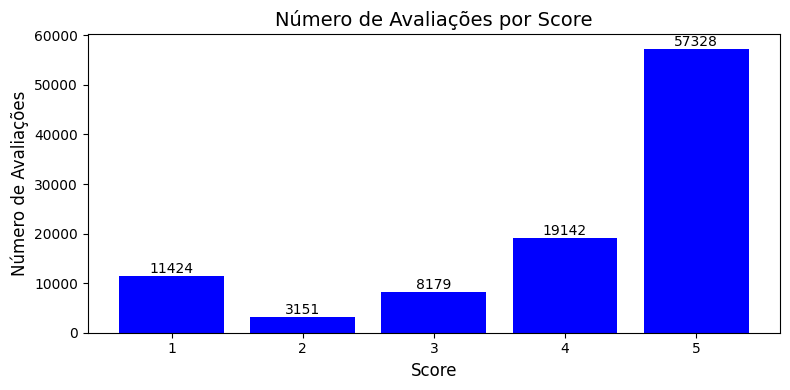

In [ ]:
avaliacoes_por_score = tabela_avaliacoes['review_score'].value_counts()

# Cria o gráfico de barras
plt.figure(figsize=(8, 4))
plt.bar(avaliacoes_por_score.index, avaliacoes_por_score.values, color='blue')

for i, valor in enumerate(avaliacoes_por_score.values):
    plt.text(avaliacoes_por_score.index[i], valor + 1, str(valor),
             ha='center', va='bottom', fontsize=10)

plt.title('Número de Avaliações por Score', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Número de Avaliações', fontsize=12)
plt.xticks(rotation=0)

# Visualizar o gráfico
plt.tight_layout()
plt.show()

### 2.4.2 - Avaliações com notas menores que 3

In [ ]:
avaliacoes_menor_3 = (tabela_avaliacoes['review_score'] < 3).sum()
avaliacoes_menor_3

qtd_avaliacoes = tabela_avaliacoes.shape[0]

porcent_avalicoes_menor_3 = (avaliacoes_menor_3/qtd_avaliacoes)*100
porcent_avalicoes_menor_3

print("Porcentagem de avaliações menores que 3 estrelas: ", porcent_avalicoes_menor_3)

Porcentagem de avaliações menores que 3 estrelas:  14.688986535515603


### Observações

- Taxa de clientes recorrentes: 3.11%
- Atraso médio das entregas: 10.62 dias
- 6535 pedidos atrasados
- Nota média de avaliação 4.1
- Taxa de avaliações menores que 3 estrelas: 14.68%


## Análises Auxiliares
- Vendas
- Pagamentos
- Receita

Agrupamentos dos pagamentos por pedido.

In [ ]:
pagamentos = tabela_pagamentos[['order_id', 'payment_value']].groupby('order_id')['payment_value'].sum().reset_index()
pagamentos

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99435,fffc94f6ce00a00581880bf54a75a037,343.40
99436,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,fffce4705a9662cd70adb13d4a31832d,116.85
99438,fffe18544ffabc95dfada21779c9644f,64.71


Agrupamentos das avaliações por pedido, visto que alguns pedidos possuem mais de uma avaliação.


In [ ]:
# Como alguns order_id têm mais de uma avaliação, fazer a média entre os order_id, depois fazer o merge do dataframe resultante com o dataframe pedidos para melhor relacionamento

avaliacoes = tabela_avaliacoes[['order_id', 'review_score']].groupby('order_id')['review_score'].mean().reset_index()
avaliacoes

,order_id,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0
...,...,...
98668,fffc94f6ce00a00581880bf54a75a037,5.0
98669,fffcd46ef2263f404302a634eb57f7eb,5.0
98670,fffce4705a9662cd70adb13d4a31832d,5.0
98671,fffe18544ffabc95dfada21779c9644f,5.0


DataFrame Pedidos: União das tabelas info_clientes e pedidos

DataFrame Vendas: União das tabelas info_produtos e itens_pedidos

In [ ]:
pedidos = pd.merge(tabela_pedidos, tabela_info_clientes, on='customer_id', how='left')
pedidos = pd.merge(pedidos, pagamentos, on='order_id', how='left')
pedidos = pd.merge(pedidos, avaliacoes, on='order_id', how='left')

pedidos.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,dias_atraso,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,5.0


In [ ]:
vendas = pd.merge(tabela_info_produtos, tabela_itens_pedido, on = 'product_id', how = 'left')
vendas = pd.merge(vendas, tabela_vendedores, on = 'seller_id', how = 'right')
vendas['payment_value'] = (vendas['price'] + vendas['freight_value'])
# vendas = pd.merge(vendas, tabela_pagamentos, on = 'order_id', how = 'left')

vendas.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,payment_value
0,ffb64e34a37740dafb6c88f1abd1fa61,esporte_lazer,26.0,417.0,3.0,700.0,43.0,15.0,35.0,4a90af3e85dd563884e2afeab1091394,1,3442f8959a84dea7ee197c632cb2df15,2017-08-25 20:50:19,106.2,9.56,13023,campinas,SP,115.76
1,325a06bcce0da45b7f4ecf2797dd40e4,esporte_lazer,44.0,1089.0,1.0,300.0,16.0,5.0,15.0,bc8a5de6abf5b14f98a6135a7fb46731,2,3442f8959a84dea7ee197c632cb2df15,2017-09-05 12:50:19,10.8,2.42,13023,campinas,SP,13.22
2,f4621f8ad6f54a2e3c408884068be46d,esporte_lazer,27.0,485.0,2.0,600.0,35.0,15.0,28.0,6d953888a914b67350d5bc4d48f2acab,1,3442f8959a84dea7ee197c632cb2df15,2017-05-11 16:25:11,101.7,15.92,13023,campinas,SP,117.62


## Análise da nota média de avaliação

In [ ]:
# Cálculo do número total de pedidos
total_pedidos = pedidos['order_id'].nunique()

# Filtro por status entregue e diferente de entregue
entregues = pedidos[pedidos['order_status'] == 'delivered']
nao_entregues = pedidos[pedidos['order_status'] != 'delivered']

# Cálculo da média de avaliação geral
avaliacao_geral = tabela_avaliacoes['review_score'].mean()

# Cálculo da média de avaliação dos pedidos entregues
avaliacao_entregues = tabela_avaliacoes[tabela_avaliacoes['order_id'].isin(entregues['order_id'])]
nota_entregues = avaliacao_entregues['review_score'].mean()

# Cálculo da média de avaliação dos pedidos não entregues
avaliacao_nao_entregues = tabela_avaliacoes[tabela_avaliacoes['order_id'].isin(nao_entregues['order_id'])]
nota_nao_entregues = avaliacao_nao_entregues['review_score'].mean()

# Percentual de avaliações com nota menor que 3
avaliacoes_menor_3 = (tabela_avaliacoes['review_score'] < 3).sum()
avaliacoes_menor_3_entregues = (avaliacao_entregues['review_score'] < 3).sum()
qtd_avaliacoes = tabela_avaliacoes.shape[0]

porcent_avalicoes_menor_3 = (avaliacoes_menor_3/qtd_avaliacoes)*100
porcent_avalicoes_menor_3_entregues = (avaliacoes_menor_3_entregues/qtd_avaliacoes)*100

print(f'Total de pedidos: {total_pedidos}\n')

print(f'Nota média de avaliação geral: {avaliacao_geral:.2f}')
print(f'Nota média de avaliação dos pedidos entregues: {nota_entregues:.2f}')
print(f'Nota média de avaliação dos pedidos não entregues: {nota_nao_entregues:.2f}\n')

print(f'Percentual de avaliações com nota menor que 3: {porcent_avalicoes_menor_3:.2f}')
print(f'Percentual de avaliações dos pedidos entregues com nota menor que 3: {porcent_avalicoes_menor_3_entregues:.2f}\n')

print("Conclusão: os pedidos que tiveram problemas na entrega tiveram menor nota media")

Total de pedidos: 99441

Nota média de avaliação geral: 4.09
Nota média de avaliação dos pedidos entregues: 4.16
Nota média de avaliação dos pedidos não entregues: 1.75

Percentual de avaliações com nota menor que 3: 14.69
Percentual de avaliações dos pedidos entregues com nota menor que 3: 12.44

Conclusão: os pedidos que tiveram problemas na entrega tiveram menor nota media


### Receita da Empresa

In [ ]:
df_conf_pagamentos = vendas[['order_id','payment_value']].groupby('order_id')['payment_value'].sum().reset_index()

registros_pagamento_faltantes = (pagamentos.shape[0] - df_conf_pagamentos.shape[0])

print(f'Existem {registros_pagamento_faltantes} pedidos sem registro de pagamento na tabela de pagamento na tabela de itens do pedido\n')

print(f'Essa possível falha/inconsistência no sistema de registros gera a falta de {registros_pagamento_faltantes*100/pagamentos.shape[0]:.2f}% das informações a respeito do frete e preço do produto\n')

print(f'Além disso, gera uma diferença de R$ {(pagamentos["payment_value"].sum() - df_conf_pagamentos["payment_value"].sum()):.2f} no cálculo da receita da empresa\n')

print(f'Receita inicial: {df_conf_pagamentos["payment_value"].sum():.2f}')
print(f'Receita recalculada: {pagamentos["payment_value"].sum():.2f}\n')

pd.concat([df_conf_pagamentos, pagamentos], axis=1).tail(5)

Existem 774 pedidos sem registro de pagamento na tabela de pagamento na tabela de itens do pedido

Essa possível falha/inconsistência no sistema de registros gera a falta de 0.78% das informações a respeito do frete e preço do produto

Além disso, gera uma diferença de R$ 165318.88 no cálculo da receita da empresa

Receita inicial: 15843553.24
Receita recalculada: 16008872.12



,order_id,payment_value,order_id,payment_value
99435,NaN,NaN,fffc94f6ce00a00581880bf54a75a037,343.40
99436,NaN,NaN,fffcd46ef2263f404302a634eb57f7eb,386.53
99437,NaN,NaN,fffce4705a9662cd70adb13d4a31832d,116.85
99438,NaN,NaN,fffe18544ffabc95dfada21779c9644f,64.71
99439,NaN,NaN,fffe41c64501cc87c801fd61db3f6244,55.79


### Indicadores de preço, receita e frete

In [ ]:
total_pedidos = pedidos['order_id'].nunique()

preco_por_pedido = vendas[['order_id', 'price']].drop_duplicates(subset=['order_id'])
preco_medio = preco_por_pedido['price'].mean()

valor_sugerido = 150

df_pedidos_acima_150 = vendas[['order_id', 'price', 'freight_value', 'payment_value']].drop_duplicates(subset=['order_id'])
df_pedidos_acima_150 = df_pedidos_acima_150[df_pedidos_acima_150['price'] > valor_sugerido]
qtde_pedidos_acima_150 = df_pedidos_acima_150['price'].count()
receita_pedidos_acima_150 = df_pedidos_acima_150['payment_value'].sum()
frete_pedidos_acima_150 = df_pedidos_acima_150['freight_value'].sum()

frete_por_pedido = vendas[['order_id', 'freight_value']].drop_duplicates(subset=['order_id'])
frete_total = frete_por_pedido['freight_value'].sum()
frete_medio = frete_por_pedido['freight_value'].mean()

# receita_total = vendas[['order_id', 'payment_value']].drop_duplicates(subset=['order_id'])
receita_total = vendas['payment_value'].sum()

produtos_total = vendas[['order_id', 'price']].drop_duplicates(subset=['order_id'])
produtos_total = produtos_total['price'].sum()

print(f'Total de pedidos: {total_pedidos}')

print(f'Preço médio por pedido: R$ {preco_medio:.2f}')
print(f'Frete médio por pedido: R$ {frete_medio:.2f}\n')

print(f'Receita total: R$ {receita_total:.2f}')
print(f'Receita sem o frete: R$ {produtos_total:.2f}')
print(f'Frete total: R$ {frete_total:.2f} ({(frete_total/receita_total)*100:.2f}% da receita total)\n')

print(f'Pedidos acima de 150 reais: {qtde_pedidos_acima_150} ({(qtde_pedidos_acima_150/total_pedidos)*100:.2f}% dos pedidos)')
print(f'Receita dos pedidos acima de 150 reais: R$ {receita_pedidos_acima_150:.2f} ({(receita_pedidos_acima_150/receita_total)*100:.2f}% da receita total)')
print(f'Frete dos pedidos acima de 150 reais: R$ {frete_pedidos_acima_150:.2f} ({(frete_pedidos_acima_150/frete_total)*100:.2f}% do frete total)\n')

lucro_desejado_150 = (valor_sugerido - (preco_medio + frete_medio))*total_pedidos
receita_com_lucro = (lucro_desejado_150/receita_total)*100

print('É evidente que 30% desses pedidos são responsáveis por mais de 50% da receita da empresa.\n')

print('Porque não oferecer frete grátis para compras acima de um valor X? (150 reais, por exemplo)\n')

print(f'Assim, resultaria em um lucro de {lucro_desejado_150:.2f} ({receita_com_lucro:.2f}% em relação à receita inicial)')

Total de pedidos: 99441
Preço médio por pedido: R$ 125.87
Frete médio por pedido: R$ 20.20

Receita total: R$ 15843553.24
Receita sem o frete: R$ 12419299.64
Frete total: R$ 1992737.59 (12.58% da receita total)

Pedidos acima de 150 reais: 20818 (20.94% dos pedidos)
Receita dos pedidos acima de 150 reais: R$ 7788005.09 (49.16% da receita total)
Frete dos pedidos acima de 150 reais: R$ 630051.87 (31.62% do frete total)

É evidente que 30% desses pedidos são responsáveis por mais de 50% da receita da empresa.

Porque não oferecer frete grátis para compras acima de um valor X? (150 reais, por exemplo)

Assim, resultaria em um lucro de 390909.35 (2.47% em relação à receita inicial)


### Valor dos Pedidos e Receita Total

In [ ]:
valor_pedidos = tabela_itens_pedido[['order_id', 'price', 'freight_value']].groupby('order_id')[['price','freight_value']].sum().reset_index()
valor_pedidos['valor_total'] = (valor_pedidos['price'] + valor_pedidos['freight_value'])
valor_pedidos

,order_id,price,freight_value,valor_total
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04
...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,43.41,343.40
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,36.53,386.53
98663,fffce4705a9662cd70adb13d4a31832d,99.90,16.95,116.85
98664,fffe18544ffabc95dfada21779c9644f,55.99,8.72,64.71


In [ ]:
qtd_clientes_recorrentes = pedidos_por_cliente[pedidos_por_cliente > 1]
clientes_recorrentes = qtd_clientes_recorrentes.reset_index()
clientes_recorrentes

pedidos_clientes_rec = clientes_e_pedidos[clientes_e_pedidos['customer_unique_id'].isin(clientes_recorrentes['customer_unique_id'])]
pedidos_clientes_rec

pedidos_clientes_rec = valor_pedidos[valor_pedidos['order_id'].isin(pedidos_clientes_rec['order_id'])]
pedidos_clientes_rec

,order_id,price,freight_value,valor_total
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
36,0017afd5076e074a48f1f1a4c7bac9c5,809.10,44.29,853.39
49,0020a222f55eb79a372d0efee3cca688,29.99,15.10,45.09
85,0035246a40f520710769010f752e7507,87.00,12.11,99.11
93,003a7f59d7e08a9c61d9e2881fe6459c,119.00,15.28,134.28
...,...,...,...,...
98547,ffabaa69e709f1ec58faf2f706c8c8ee,144.41,17.45,161.86
98557,ffb47bf24e3f64dc0a2059a9181b976a,46.90,9.34,56.24
98624,ffe49171e120186dcc4c444b55691810,68.00,8.85,76.85
98639,ffee31fb4b5e35c9123608015637c495,99.00,13.52,112.52


In [ ]:
produto_medio = valor_pedidos['price'].mean()
frete_medio = valor_pedidos['freight_value'].mean()
ticket_medio = valor_pedidos['valor_total'].mean()


print(f"Valor Médio do Produto: {produto_medio:.2f}")
print(f"Valor Médio do Frete: {frete_medio: .2f}")
print(f"Ticket Médio: {ticket_medio: .2f}")

Valor Médio do Produto: 137.75
Valor Médio do Frete:  22.82
Ticket Médio:  160.58


In [ ]:
itens_pedidos_atrasados = pd.merge(pedidos_atrasados[['order_id','dias_atraso']], tabela_itens_pedido[['order_id', 'product_id']], on='order_id', how='left')
itens_pedidos_atrasados = pd.merge(itens_pedidos_atrasados, tabela_info_produtos[['product_id', 'product_category_name']], on='product_id', how='left')

itens_pedidos_atrasados = itens_pedidos_atrasados.dropna(subset=['dias_atraso'])
itens_pedidos_atrasados = itens_pedidos_atrasados.dropna(subset=['product_category_name'])

itens_pedidos_atrasados.drop('product_id', axis=1,inplace=True)

itens_pedidos_atrasados


,order_id,dias_atraso,product_category_name
0,203096f03d82e0dffbc41ebc2e2bcfb7,11.0,beleza_saude
1,fbf9ac61453ac646ce8ad9783d7d0af6,9.0,cool_stuff
2,6ea2f835b4556291ffdc53fa0b3b95e8,7.0,utilidades_domesticas
3,66e4624ae69e7dc89bd50222b59f581f,1.0,telefonia
4,66e4624ae69e7dc89bd50222b59f581f,1.0,telefonia
...,...,...,...
7259,b3112ca67f3afd4e20cf2ee91fc4f804,5.0,moveis_quarto
7260,0fa1fab1d7c1211c824596ed5e111e3c,3.0,beleza_saude
7261,38e9133ce29f6bbe35aed9c3863dce01,21.0,bebes
7262,d692ef54145c9cb3322ec2e5508aa3f4,2.0,moveis_sala


### Categorização

In [ ]:
categorias = categorias = pd.read_excel("https://raw.githubusercontent.com/KassiaLopes/Mercado-Orbita/main/data/interim/Categorias.xlsx")

In [ ]:
categorizacao = itens_pedidos_atrasados.merge(categorias, on='product_category_name', how='left')


#Se tiver mais de 1 categoria → "Misto"
pedidos_atrasados_com_categoria = categorizacao.groupby("order_id")["categoria"].unique().reset_index()
pedidos_atrasados_com_categoria["categoria_final"] = pedidos_atrasados_com_categoria["categoria"].apply(
    lambda x: "Misto" if len(x) > 1 else x[0]
)

pedidos_atrasados_com_categoria

,order_id,categoria,categoria_final
0,000e906b789b55f64edcb1f84030f90d,"[ELETRONICOS,INFORMATICA E AUDIO]","ELETRONICOS,INFORMATICA E AUDIO"
1,0017afd5076e074a48f1f1a4c7bac9c5,"[ELETRONICOS,INFORMATICA E AUDIO]","ELETRONICOS,INFORMATICA E AUDIO"
2,001c85b5f68d2be0cb0797afc9e8ce9a,[CASA E CONFORTO],CASA E CONFORTO
3,001d8f0e34a38c37f7dba2a37d4eba8b,[MODA E BELEZA],MODA E BELEZA
4,0030d783f979fbc5981e75613b057344,[CASA E CONFORTO],CASA E CONFORTO
...,...,...,...
6434,ffdd178654127ccf34a439e8704fecd9,[MODA E BELEZA],MODA E BELEZA
6435,ffecd5a79a0084f6a592288c67e3c298,"[ELETRONICOS,INFORMATICA E AUDIO]","ELETRONICOS,INFORMATICA E AUDIO"
6436,ffefb169ddf34cecc0622a6d3cc387f8,[ARTES E DECORACAO],ARTES E DECORACAO
6437,fff2cdc825f9fc0ba3c04227cfa02303,"[ELETRONICOS,INFORMATICA E AUDIO]","ELETRONICOS,INFORMATICA E AUDIO"


In [ ]:
atraso_categorias = pd.merge(pedidos_atrasados_com_categoria, tabela_pedidos[['order_id','dias_atraso']], on='order_id', how='left')
atraso_categorias.drop(columns=['categoria'], inplace=True)

atraso_categorias['dias_atraso'] = atraso_categorias['dias_atraso'].astype(int)
atraso_categorias

,order_id,categoria_final,dias_atraso
0,000e906b789b55f64edcb1f84030f90d,"ELETRONICOS,INFORMATICA E AUDIO",2
1,0017afd5076e074a48f1f1a4c7bac9c5,"ELETRONICOS,INFORMATICA E AUDIO",4
2,001c85b5f68d2be0cb0797afc9e8ce9a,CASA E CONFORTO,8
3,001d8f0e34a38c37f7dba2a37d4eba8b,MODA E BELEZA,2
4,0030d783f979fbc5981e75613b057344,CASA E CONFORTO,22
...,...,...,...
6434,ffdd178654127ccf34a439e8704fecd9,MODA E BELEZA,3
6435,ffecd5a79a0084f6a592288c67e3c298,"ELETRONICOS,INFORMATICA E AUDIO",7
6436,ffefb169ddf34cecc0622a6d3cc387f8,ARTES E DECORACAO,5
6437,fff2cdc825f9fc0ba3c04227cfa02303,"ELETRONICOS,INFORMATICA E AUDIO",6


In [ ]:
atraso_medio_por_categoria = atraso_categorias.groupby('categoria_final')['dias_atraso'].mean().reset_index()
atraso_medio_por_categoria.sort_values(by='dias_atraso', ascending=False)

,categoria_final,dias_atraso
1,ALIMENTOS,13.666667
3,AUTOMOTIVO,12.348921
14,SERVIÇOS,11.545455
4,BEBES,11.455357
11,MOVEIS E ELETRODOMESTICOS,11.436834
2,ARTES E DECORACAO,11.129870
5,BRINQUEDOS E LAZER,10.891008
6,CASA E CONFORTO,10.876173
8,FERRAMENTAS E CONSTRUCAO,10.650430
9,"LIVROS, MUSICA E PAPELARIA",10.363636


In [ ]:
receita = pd.merge(valor_pedidos, tabela_pedidos[['order_id', 'order_approved_at']], on='order_id', how='left')
receita.drop(columns=['price', 'freight_value'], inplace=True)
receita

,order_id,valor_total,order_approved_at
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2017-09-13 09:45:35
1,00018f77f2f0320c557190d7a144bdd3,259.83,2017-04-26 11:05:13
2,000229ec398224ef6ca0657da4fc703e,216.87,2018-01-14 14:48:30
3,00024acbcdf0a6daa1e931b038114c75,25.78,2018-08-08 10:10:18
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,2017-02-04 14:10:13
...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,343.40,2018-04-25 04:11:01
98662,fffcd46ef2263f404302a634eb57f7eb,386.53,2018-07-17 04:31:48
98663,fffce4705a9662cd70adb13d4a31832d,116.85,2017-10-24 17:14:25
98664,fffe18544ffabc95dfada21779c9644f,64.71,2017-08-15 00:04:32


# Descobertas Importantes

- Apenas **5.3%** dos pedidos tem atrasos superiores a 2 dias (Valor reportado: 22%)
- As avaliações abaixo de 3 estrelas correspondem a **14.68%** (Valor reporatado: 18%)


- O atraso médio das entregas gira em torno de **10,62 dias** (Valor Reportado: 2,3 dias)
- A nota média de avaliação é aproximadamente **4,1**.
- <span style="color: red"> A taxa de clientes recorrentes está em **3.11%** (Valor reportado: 12%)</span>

# Pontos Importantes

- Agrupamento das categorias de produtos em categorias macro, agrupando aquelas com caractéristicas semelhante, com o intuito de facilitar a análise.
- Definição de **novas metas**;
- **Priorizar** a **taxa de clientes recorrentes** e **atraso médio nas entregas**;

# Exportando Bases para o Power BI

In [ ]:
valor_pedidos.to_csv('valor_pedidos.csv', index=False)
pedidos_clientes_rec.to_csv('pedidos_clientes_rec.csv', index=False)
pedidos_atrasados_com_categoria.to_csv('pedidos_atrasados_por_categoria.csv')
atraso_categorias.to_csv('atraso_categorias.csv')
receita.to_csv('receita.csv')